## 모델4

모델2와 모델3을 7:3으로 가중치 설정하여 새로운 모델을 생성

In [1]:
!pip install -q segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def fuse_masks(mask1_path, mask3_path, method='conditional_or', weight1=0.7, weight3=0.3):
    mask1 = cv2.imread(mask1_path, cv2.IMREAD_GRAYSCALE)
    mask3 = cv2.imread(mask3_path, cv2.IMREAD_GRAYSCALE)

    if mask1 is None or mask3 is None:
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {mask1_path} 또는 {mask3_path}")

    mask1_bin = (mask1 > 127).astype(np.uint8)
    mask3_bin = (mask3 > 127).astype(np.uint8)

    if method == 'conditional_or':
        fused = np.where((mask1_bin == 1) | (mask3_bin == 1), 255, 0).astype(np.uint8)

    elif method == 'weighted':
        fused = (weight1 * mask1_bin + weight3 * mask3_bin) * 255
        fused = (fused > 127).astype(np.uint8) * 255

    else:
        raise ValueError("지원하지 않는 통합 방식입니다.")

    return fused

def fuse_all_masks(mask1_dir, mask3_dir, fused_dir, method='conditional_or'):
    os.makedirs(fused_dir, exist_ok=True)

    # 기준이 되는 train 마스크 목록 (예: Defective_0001_mask.png)
    mask1_filenames = sorted(os.listdir(mask1_dir))

    for fname in tqdm(mask1_filenames, desc="Fusing Train Masks Only"):
        base_name = os.path.splitext(fname)[0].replace("_mask", "")
        mask1_path = os.path.join(mask1_dir, fname)
        mask3_fname = f"{base_name}_mask.png"
        mask3_path = os.path.join(mask3_dir, mask3_fname)
        save_path = os.path.join(fused_dir, f"{base_name}_mask.png")

        try:
            fused_mask = fuse_masks(mask1_path, mask3_path, method=method)
            cv2.imwrite(save_path, fused_mask)
        except FileNotFoundError as e:
            print(e)

if __name__ == "__main__":
    mask1_dir = "/content/drive/MyDrive/Colab Notebooks/KDT_SF_8/최종 프로젝트/model2_mask"  # train 마스크
    mask3_dir = "/content/drive/MyDrive/Colab Notebooks/KDT_SF_8/최종 프로젝트/model3_mask"  # 전체 마스크
    fused_dir = "/content/drive/MyDrive/Colab Notebooks/KDT_SF_8/최종 프로젝트/model4_mask"

    fuse_all_masks(mask1_dir, mask3_dir, fused_dir, method='weighted')


Fusing Train Masks Only: 100%|██████████| 157/157 [01:57<00:00,  1.34it/s]


In [3]:
# 모델 평가 함수

# -------------------------------
# Dice Metric
# -------------------------------
def dice_coef(preds, targets, threshold=0.5):
    preds = (preds > threshold).float()
    intersection = (preds * targets).sum()
    return (2. * intersection) / (preds.sum() + targets.sum() + 1e-6)


def iou_score(preds, targets, threshold=0.5):
    preds = (preds > threshold).float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return intersection / (union + 1e-6)

In [7]:
# UNet++ & resnet34 encoding

import os
import random
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

import segmentation_models_pytorch as smp

# -------------------------------
# Augmentation Function
# -------------------------------

def custom_augment_fn(image, mask):
    if random.random() < 0.5:
        image = TF.hflip(image)
        mask = TF.hflip(mask)
    if random.random() < 0.5:
        image = TF.vflip(image)
        mask = TF.vflip(mask)
    if random.random() < 0.5:
        angle = random.uniform(-15, 15)
        image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
        mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)
    if random.random() < 0.5:
        scale = random.uniform(0.9, 1.1)
        w, h = image.size
        new_size = (int(h * scale), int(w * scale))
        image = TF.resize(image, new_size, interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, new_size, interpolation=InterpolationMode.NEAREST)
        image = TF.center_crop(image, (256, 256))
        mask = TF.center_crop(mask, (256, 256))
    return image, mask

# -------------------------------
# Custom Dataset
# -------------------------------
class CrackDataset(Dataset):
    def __init__(self, image_dir, mask_dir, augment_fn=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = sorted(os.listdir(image_dir))
        self.augment_fn = augment_fn
        self.target_size = (256, 256)  # 고정 크기 설정

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        image_name = self.filenames[idx]
        img_path = os.path.join(self.image_dir, image_name)
        mask_path = os.path.join(self.mask_dir, image_name.replace(".jpg", "_pseudo_mask.png"))

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.augment_fn:
            image, mask = self.augment_fn(image, mask)

        # 항상 256x256으로 리사이즈 (augmentation 적용 후에도 보장)
        image = TF.resize(image, self.target_size, interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.target_size, interpolation=InterpolationMode.NEAREST)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406],
                                      std=[0.229, 0.224, 0.225])
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        return image, mask


def train_with_fused_masks():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dataset = CrackDataset(
        image_dir="/content/drive/MyDrive/Colab Notebooks/KDT_SF_8/최종 프로젝트/Defective_train",
        mask_dir="/content/drive/MyDrive/Colab Notebooks/KDT_SF_8/최종 프로젝트/model4_mask",  # <-- 변경된 경로
        augment_fn=custom_augment_fn
    )

    dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)

    model = smp.UnetPlusPlus(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    ).to(device)

    loss_fn = smp.losses.DiceLoss(mode='binary')
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    best_dice = 0.0

    for epoch in range(25):
        model.train()
        total_loss = 0
        total_dice = 0
        total_iou = 0

        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}", leave=False)

        for images, masks in progress_bar:
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            loss = loss_fn(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_loss = loss.item()
            batch_dice = dice_coef(preds, masks).item()
            batch_iou = iou_score(preds, masks).item()

            total_loss += batch_loss
            total_dice += batch_dice
            total_iou += batch_iou

            progress_bar.set_postfix({
                "Loss": f"{batch_loss:.4f}",
                "Dice": f"{batch_dice:.4f}",
                "IoU": f"{batch_iou:.4f}"
            })

        avg_dice = total_dice / len(dataloader)

        if avg_dice > best_dice:
            best_dice = avg_dice
            torch.save(model.state_dict(),
                       "/content/drive/MyDrive/Colab Notebooks/KDT_SF_8/최종 프로젝트/best_model4.pth")
            print(f"✅ Best model saved at epoch {epoch+1} with Dice: {best_dice:.4f}")

        print(f"[Epoch {epoch+1}] Loss: {total_loss/len(dataloader):.4f} | ",
              f"Dice: {avg_dice:.4f} | IoU: {total_iou/len(dataloader):.4f}")


if __name__ == '__main__':
    train_with_fused_masks()


✅ Best model saved at epoch 1 with Dice: 0.5149
[Epoch 1] Loss: 0.6533 |  Dice: 0.5149 | IoU: 0.3533


✅ Best model saved at epoch 2 with Dice: 0.5908
[Epoch 2] Loss: 0.6087 |  Dice: 0.5908 | IoU: 0.4291


✅ Best model saved at epoch 3 with Dice: 0.6505
[Epoch 3] Loss: 0.5520 |  Dice: 0.6505 | IoU: 0.4904


[Epoch 4] Loss: 0.5385 |  Dice: 0.6369 | IoU: 0.4766


[Epoch 5] Loss: 0.5186 |  Dice: 0.6485 | IoU: 0.4956


...

[Epoch 21] Loss: 0.3288 |  Dice: 0.7483 | IoU: 0.6031


[Epoch 22] Loss: 0.3307 |  Dice: 0.7401 | IoU: 0.5950


[Epoch 23] Loss: 0.3370 |  Dice: 0.7401 | IoU: 0.5973


✅ Best model saved at epoch 24 with Dice: 0.7748
[Epoch 24] Loss: 0.2881 |  Dice: 0.7748 | IoU: 0.6361


✅ Best model saved at epoch 25 with Dice: 0.7865
[Epoch 25] Loss: 0.2776 |  Dice: 0.7865 | IoU: 0.6501


In [11]:
# Crop Size: (227, 227)
# Stride: 50
# Sharpening: 커널 기반 필터 적용

import cv2
import numpy as np
from PIL import Image
import torch
import torchvision.transforms.functional as TF
import os
from tqdm import tqdm
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

def sharpen_image(img_pil):
    img_cv = np.array(img_pil)
    kernel = np.array([[0, -1, 0],
                       [-1,  5,-1],
                       [0, -1, 0]])
    sharpened = cv2.filter2D(img_cv, -1, kernel)
    return Image.fromarray(sharpened)

def slide_crop(image, crop_size=(227, 227), stride=50):
    w, h = image.size
    crops, coords = [], []
    for y in range(0, h - crop_size[1] + 1, stride):
        for x in range(0, w - crop_size[0] + 1, stride):
            box = (x, y, x + crop_size[0], y + crop_size[1])
            crop = image.crop(box)
            crops.append(crop)
            coords.append((x, y))
    return crops, coords

def stitch_mask(crop_preds, coords, image_size, crop_size=(227, 227)):
    full_mask = np.zeros(image_size, dtype=np.float32)
    count_map = np.zeros(image_size, dtype=np.float32)

    for crop_pred, (x, y) in zip(crop_preds, coords):
        crop_np = np.array(crop_pred.resize(crop_size))
        full_mask[y:y+crop_size[1], x:x+crop_size[0]] += crop_np
        count_map[y:y+crop_size[1], x:x+crop_size[0]] += 1.0

    count_map[count_map == 0] = 1.0
    stitched = (full_mask / count_map).astype(np.uint8)
    return stitched

def generate_crop_pseudo_mask(model, device, image_path, save_dir, crop_size=(227,227), stride=50, min_area=20):
    os.makedirs(save_dir, exist_ok=True)
    image = Image.open(image_path).convert("RGB")
    crops, coords = slide_crop(image, crop_size=crop_size, stride=stride)

    preds = []
    for crop in crops:
        crop = sharpen_image(crop)
        input_tensor = TF.to_tensor(TF.resize(crop, (256, 256)))
        input_tensor = TF.normalize(input_tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        input_tensor = input_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = torch.sigmoid(model(input_tensor)).squeeze().cpu().numpy()
            pred_mask = (pred > 0.5).astype(np.uint8) * 255
            preds.append(Image.fromarray(pred_mask))

    stitched_mask = stitch_mask(preds, coords, image.size[::-1], crop_size=crop_size)

    # 마스크 저장
    base_name = os.path.basename(image_path)
    name_no_ext = os.path.splitext(base_name)[0]
    save_path = os.path.join(save_dir, f"{name_no_ext}_pseudo_mask.png")
    Image.fromarray(stitched_mask).save(save_path)

    # 크랙 필터링: 너무 작은 크랙 제외
    binary_mask = (stitched_mask > 127).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask)

    filtered_mask = np.zeros_like(binary_mask)
    crack_count = 0
    for i in range(1, num_labels):  # 0은 배경
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            filtered_mask[labels == i] = 1
            crack_count += 1

    crack_area_ratio = np.sum(filtered_mask) / (binary_mask.shape[0] * binary_mask.shape[1])

    print(f"[{name_no_ext}] Crack count: {crack_count}, Area ratio: {crack_area_ratio:.4f}")

    # 최종 마스크 저장
    filtered_save_path = os.path.join(save_dir, f"{name_no_ext}_filtered_mask.png")
    Image.fromarray((filtered_mask * 255).astype(np.uint8)).save(filtered_save_path)

    return filtered_mask, crack_count, crack_area_ratio



def visualize_pseudo_mask(image_path, mask_path):
    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Pseudo Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def process_folder(model_path, image_folder, save_dir, crop_size=(227, 227), stride=50, visualize=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = smp.UnetPlusPlus(encoder_name='resnet34', encoder_weights=None, in_channels=3, classes=1)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    os.makedirs(save_dir, exist_ok=True)

    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

    for img_file in tqdm(image_files, desc="Processing images"):
        img_path = os.path.join(image_folder, img_file)
        generate_crop_pseudo_mask(model, device, img_path, save_dir, crop_size, stride)
        if visualize:
            pseudo_mask_path = os.path.join(save_dir, os.path.splitext(img_file)[0] + "_pseudo_mask.png")
            visualize_pseudo_mask(img_path, pseudo_mask_path)

def visualize_crack_classes_transparent(image_path, crack_areas, labels, min_area=20, save_path=None):
    image = np.array(Image.open(image_path).convert("RGB"))
    overlay = np.zeros_like(image, dtype=np.uint8)

    # 유효 크랙 필터링
    filtered = [(i, area) for i, area in enumerate(crack_areas) if area >= min_area]
    if not filtered:
        print("min_area 이상인 크랙이 없습니다.")
        return [0, 0, 0, 0]

    indices, areas = zip(*filtered)
    min_val, max_val = min_area, max(areas)
    bins = np.linspace(min_val, max_val, 5)  # 4구간

    # 색상: 초록 → 노랑 → 주황 → 빨강
    colors = [
        (0, 255, 0),
        (255, 255, 0),
        (255, 165, 0),
        (255, 0, 0)
    ]

    count_per_bin = [0] * 4
    for idx, area in filtered:
        bin_idx = np.digitize(area, bins, right=True) - 1
        bin_idx = min(max(bin_idx, 0), 3)
        count_per_bin[bin_idx] += 1
        overlay[labels == idx + 1] = colors[bin_idx]

    # 알파 블렌딩
    blended = cv2.addWeighted(image, 0.7, overlay, 0.3, 0)

    # 시각화
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(blended)
    plt.title("Crack Overlay (min_area ~ max, 4 Color Ranges)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.pie(count_per_bin,
            labels=[f"Range {i+1}" for i in range(4)],
            autopct='%1.1f%%',
            colors=[np.array(c)/255 for c in colors])
    plt.title("Crack Count per Area Range")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

    return count_per_bin

[Defective (115)] Crack count: 39, Area ratio: 0.6003


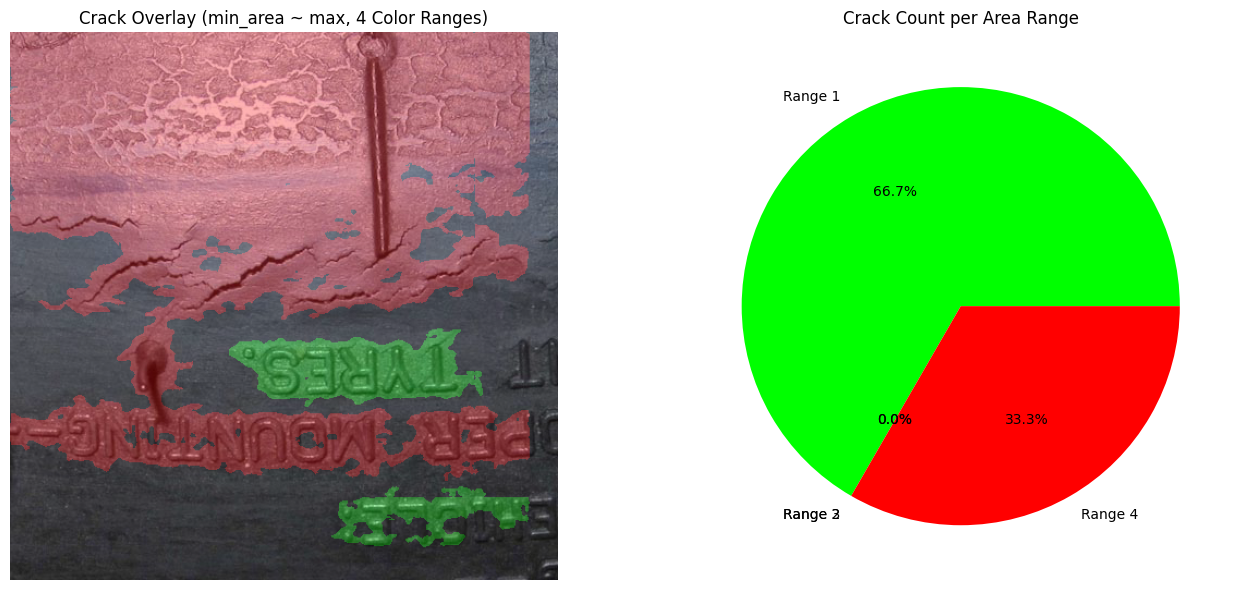

[2, 0, 0, 1]

In [12]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import segmentation_models_pytorch as smp

# ==== 사용자 설정 ====
model_path = "/content/drive/MyDrive/Colab Notebooks/KDT_SF_8/최종 프로젝트/best_model4.pth"
image_path = "/content/drive/MyDrive/Colab Notebooks/KDT_SF_8/최종 프로젝트/Defective_train/Defective (115).jpg"
save_dir = "/content/drive/MyDrive/Colab Notebooks/KDT_SF_8/최종 프로젝트/삭제예정"
PIXEL_TO_MM = 0.1
min_area = 30

os.makedirs(save_dir, exist_ok=True)

# ==== 모델 로드 ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.UnetPlusPlus(encoder_name='resnet34', encoder_weights=None, in_channels=3, classes=1)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# ==== 마스크 생성 ====
filtered_mask, crack_count, area_ratio = generate_crop_pseudo_mask(
    model, device, image_path, save_dir,
    crop_size=(227, 227), stride=50, min_area=min_area
)

# ==== 크랙 면적 및 라벨 분석 ====
def analyze_cracks(mask, min_area=20):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8))

    crack_areas_mm2 = []
    valid_labels = np.zeros_like(labels)

    for i in range(1, num_labels):  # 0은 배경
        area_pixels = stats[i, cv2.CC_STAT_AREA]
        if area_pixels < min_area:
            continue

        area_mm2 = area_pixels * (PIXEL_TO_MM ** 2)
        crack_areas_mm2.append(area_mm2)
        valid_labels[labels == i] = len(crack_areas_mm2)

    return crack_areas_mm2, valid_labels

crack_areas_mm2, valid_labels = analyze_cracks(filtered_mask, min_area)

# ==== 시각화 함수: 크랙 색상 및 파이차트 ====
def visualize_crack_classes(image_path, crack_areas, labels, save_path=None):
    image = np.array(Image.open(image_path).convert("RGB"))
    overlay = image.copy()

    # 구간 설정
    min_area, max_area = min(crack_areas), max(crack_areas)
    bins = np.linspace(min_area, max_area, 6)  # 5개 구간
    bin_indices = np.digitize(crack_areas, bins, right=True) - 1

    # 색상 설정 (빨-주-노-초-파)
    colors = [(255, 0, 0), (255, 165, 0), (255, 255, 0), (0, 255, 0), (0, 0, 255)]
    count_per_bin = [0] * 5

    for i, bin_idx in enumerate(bin_indices):
        count_per_bin[bin_idx] += 1
        overlay[labels == i + 1] = colors[bin_idx]

    # 시각화
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(overlay)
    plt.title("Crack Overlay by Size Range")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.pie(count_per_bin,
            labels=[f"Range {i+1}" for i in range(5)],
            autopct='%1.1f%%',
            colors=[np.array(c)/255 for c in colors])
    plt.title("Crack Count per Size Range")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

# ==== 시각화 실행 ====
visualize_crack_classes_transparent(
    image_path=image_path,
    crack_areas=crack_areas_mm2,
    labels=valid_labels,
    save_path=os.path.join(save_dir, "crack_transparent_colormap.png")
)
